# Homework 04: Building CNNs for Image Classification

### Due: September 27th at 11:59pm (with 2-hour + 1 minute grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects.

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework.


In [1]:
pip install kagglehub

In [2]:
pip install tensorflow kagglehub scikit-learn matplotlib numpy pillow

## 1. Setup and Data Loading


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf
from tensorflow.keras import layers, Input, models, callbacks, regularizers,initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.optimizers import Adam,AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [4]:

def plot_learning_curves(hist, title, verbose=True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Testing and training sets already defined, accessed here as global variables

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [5]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model,
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [6]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

Using Colab cache for faster access to the 'intel-image-classification' dataset.


In [7]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 0.5

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



### Examine The Dataset

In [8]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 5614 val examples: 1402 test examples: 1498
train per-class counts: {'buildings': 876, 'forest': 908, 'glacier': 962, 'mountain': 1005, 'sea': 910, 'street': 953}
val per-class counts: {'buildings': 219, 'forest': 227, 'glacier': 240, 'mountain': 251, 'sea': 227, 'street': 238}
test per-class counts: {'buildings': 218, 'forest': 237, 'glacier': 276, 'mountain': 262, 'sea': 255, 'street': 250}


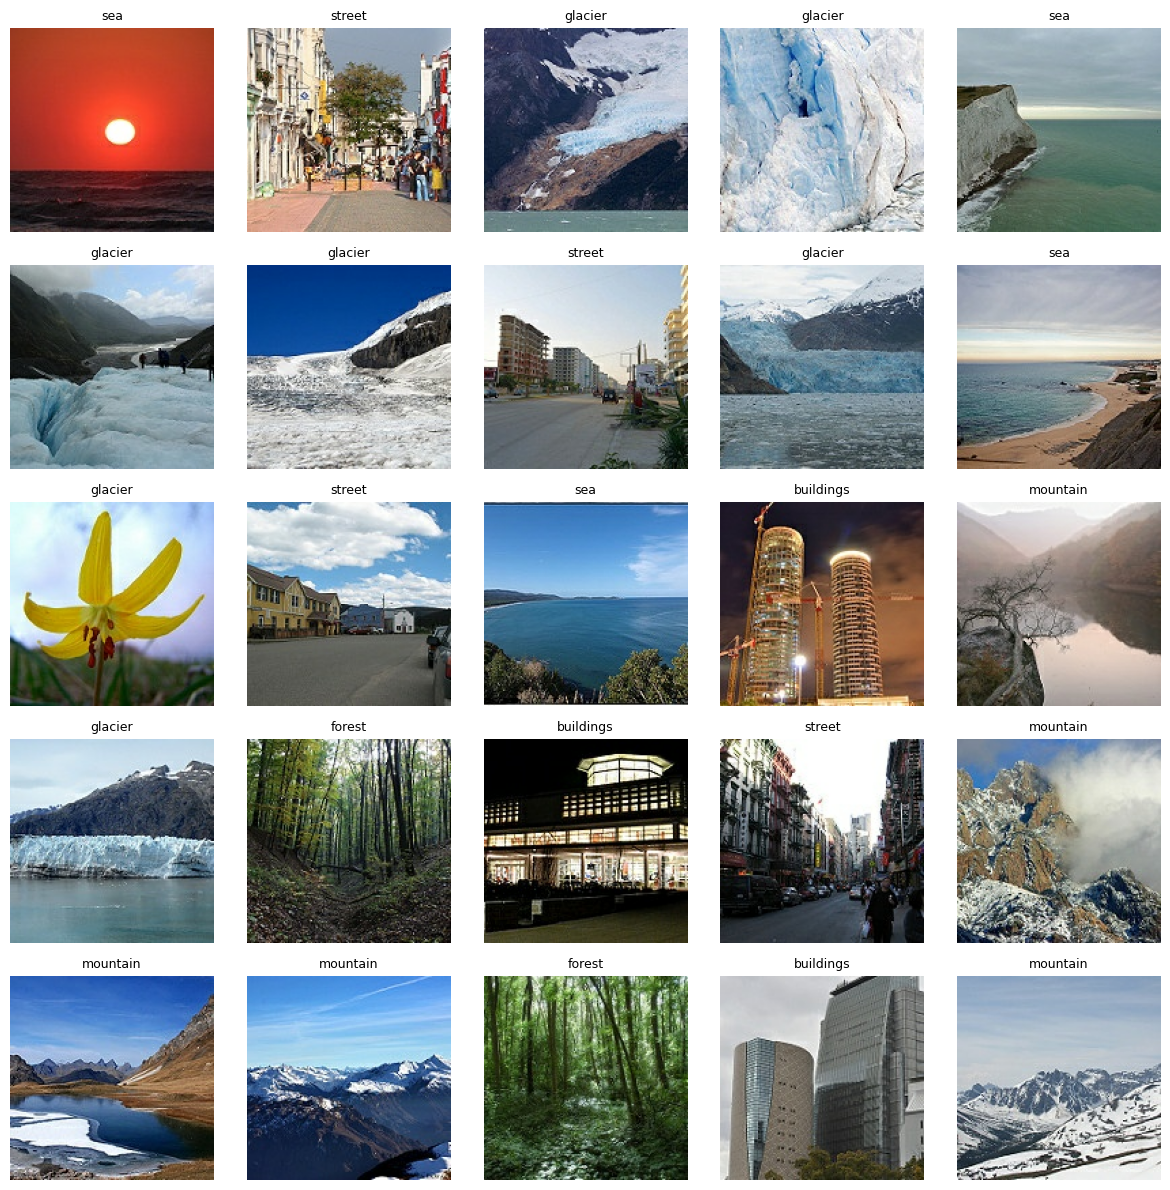

In [9]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

# Take one batch from the dataset
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!).

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in.


> **Note:** On rare runs, training may become numerically unstable and produce `NaN` loss values. If this occurs, rerun the model. If the problem persists, restart the runtime and run the notebook again from the beginning.


Baseline Model



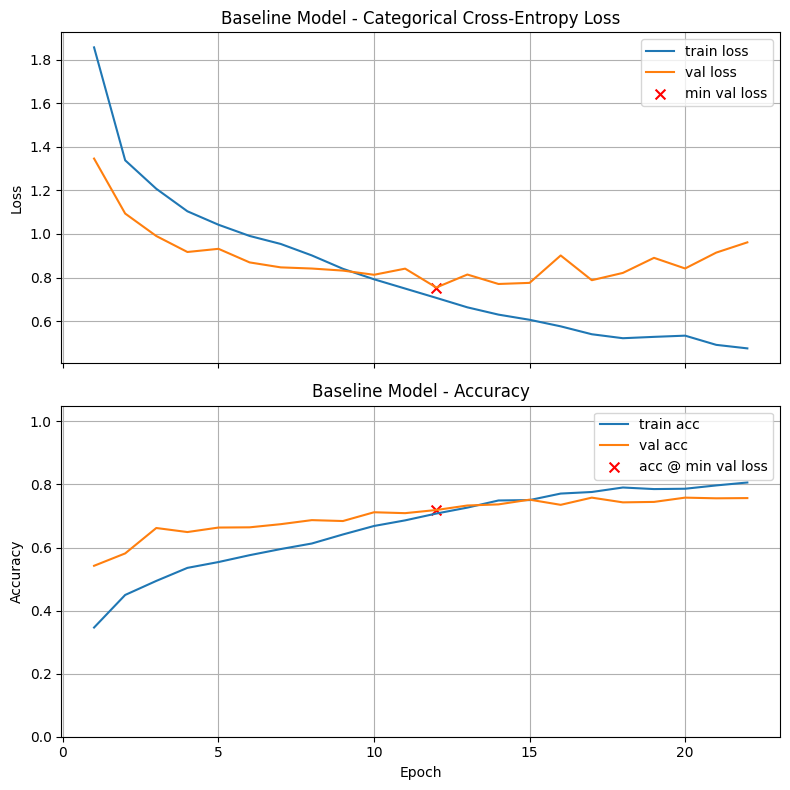

Final Training Loss:            0.4745
Final Training Accuracy:        0.8062
Final Validation Loss:          0.9616
Final Validation Accuracy:      0.7568
Minimum Validation Loss:        0.7542 (Epoch 12)
Validation Accuracy @ Min Loss: 0.7190

Test Loss: 0.7758
Test Accuracy: 0.7276

Validation-Test Gap (accuracy): 0.008664

Execution Time: 00:02:19


In [10]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer.
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5).


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).

In [11]:
# Your code here, add additional cells if you wish

def build_cnn(conv_filters=(32, 64), dense_units=64, dropout=0.5, l2=None,
              batch_norm=False, head="flatten"):
    he = initializers.HeNormal()
    reg = regularizers.l2(l2) if l2 else None
    model = models.Sequential()
    model.add(Input(shape=INPUT_SHAPE))
    for i, f in enumerate(conv_filters):
        model.add(Conv2D(f, (3, 3), activation="relu", kernel_initializer=he, padding="same"))
        if batch_norm:
            model.add(BatchNormalization())
        is_last = (i == len(conv_filters) - 1)
        if not (is_last and head != "flatten"):
            model.add(MaxPooling2D(2))
    if head == "gap":
        model.add(GlobalAveragePooling2D())
    elif head == "gmp":
        model.add(GlobalMaxPooling2D())
    else:
        model.add(Flatten())
        model.add(Dense(dense_units, activation="relu", kernel_initializer=he, kernel_regularizer=reg))
        model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation="softmax"))
    return model

def run_experiment(title, lr, cfg, callbacks=None):
    model = build_cnn(**cfg)
    train_and_test(model, lr_schedule=lr, title=title, callbacks=callbacks or [])
    return results[title][0]

def val_acc(title):
    return results[title][0]

BASE = dict(conv_filters=(32, 64), dense_units=64, dropout=0.5)

P1 = {
    1: ("P1 Tweak 1 lr=5e-4",        5e-4, dict(BASE)),
    3: ("P1 Tweak 3 conv 32-64-128", 1e-3, dict(BASE, conv_filters=(32, 64, 128))),
    6: ("P1 Tweak 6 dropout=0.3",    1e-3, dict(BASE, dropout=0.3)),
}


P1 Tweak 1 lr=5e-4



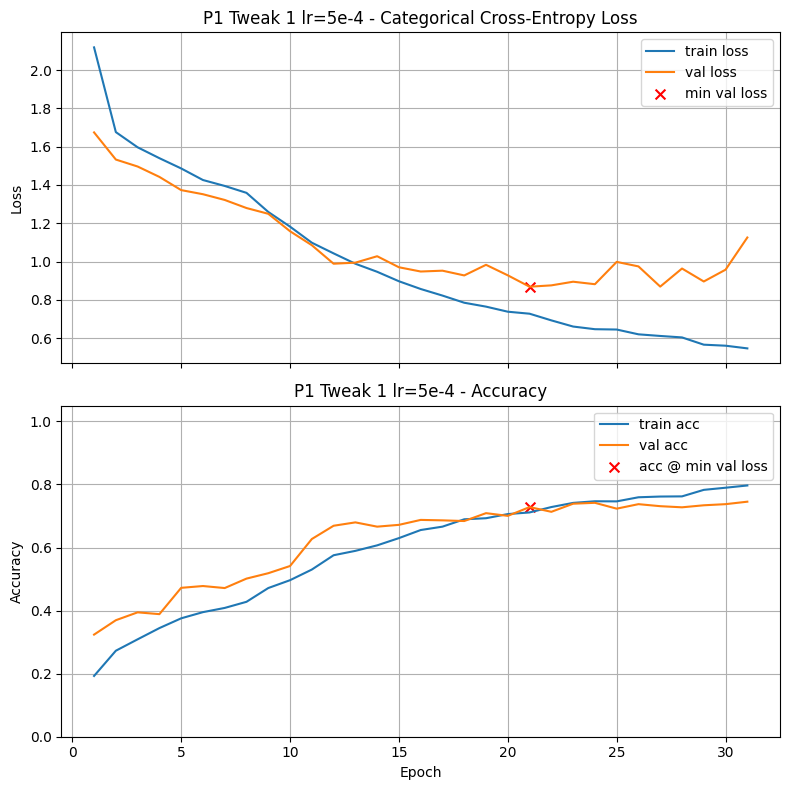

Final Training Loss:            0.5467
Final Training Accuracy:        0.7968
Final Validation Loss:          1.1256
Final Validation Accuracy:      0.7454
Minimum Validation Loss:        0.8687 (Epoch 21)
Validation Accuracy @ Min Loss: 0.7282

Test Loss: 0.8923
Test Accuracy: 0.7130

Validation-Test Gap (accuracy): 0.015295

Execution Time: 00:02:35


0.7282453775405884

In [12]:
title, lr, cfg = P1[1]
run_experiment(title, lr, cfg)


P1 Tweak 3 conv 32-64-128



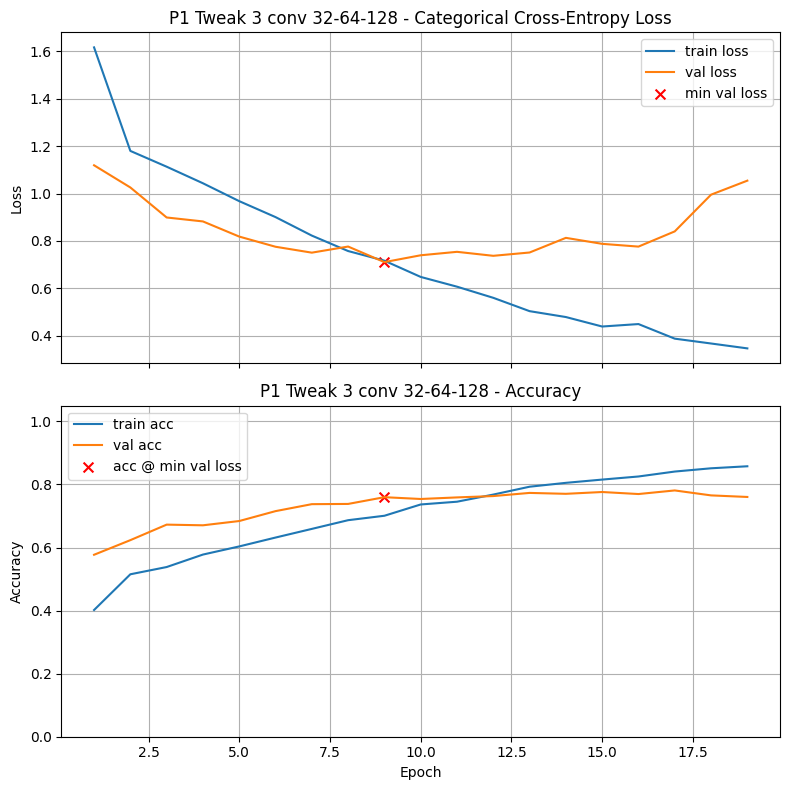

Final Training Loss:            0.3467
Final Training Accuracy:        0.8577
Final Validation Loss:          1.0542
Final Validation Accuracy:      0.7603
Minimum Validation Loss:        0.7106 (Epoch 9)
Validation Accuracy @ Min Loss: 0.7596

Test Loss: 0.7358
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.004622

Execution Time: 00:01:56


0.7596291303634644

In [13]:
title, lr, cfg = P1[3]
run_experiment(title, lr, cfg)


P1 Tweak 6 dropout=0.3



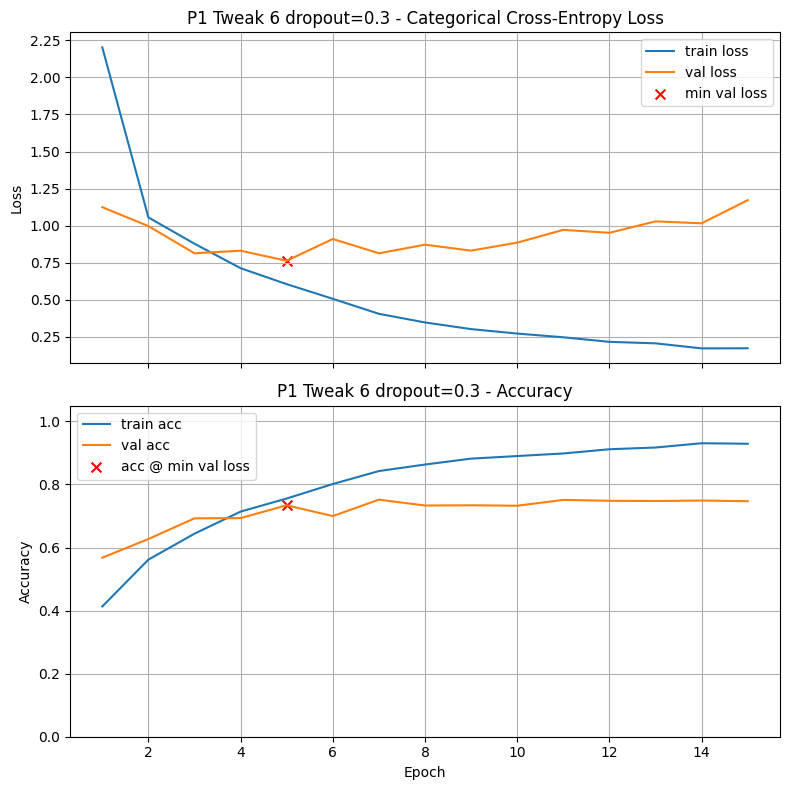

Final Training Loss:            0.1730
Final Training Accuracy:        0.9291
Final Validation Loss:          1.1721
Final Validation Accuracy:      0.7468
Minimum Validation Loss:        0.7634 (Epoch 5)
Validation Accuracy @ Min Loss: 0.7340

Test Loss: 0.7755
Test Accuracy: 0.7377

Validation-Test Gap (accuracy): 0.003699

Execution Time: 00:01:18


0.7339515089988708

In [14]:
title, lr, cfg = P1[6]
run_experiment(title, lr, cfg)

### Graded Questions

In [15]:
# Set a1a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

p1_best = max(P1, key=lambda t: val_acc(P1[t][0]))
a1a = p1_best if val_acc(P1[p1_best][0]) > val_acc("Baseline Model") else -1             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [16]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a}')


a1a = 3


In [21]:
# Set a1b to the validation accuracy found by the choice specified in Question a1a.

a1b = val_acc(P1[p1_best][0])             # Replace 0.0 with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1b = {a1b:.4f}')

a1b = 0.7596


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence.

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design.
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.



In [23]:
# Your code here, add additional cells if you wish

if a1a == -1:
    P1_BEST_LR, P1_BEST_CFG = 1e-3, dict(BASE)
else:
    _, P1_BEST_LR, P1_BEST_CFG = P1[p1_best]

P2_CFG = dict(P1_BEST_CFG, batch_norm=True)

P2 = {
    0: ("P2 BN only",                                  P1_BEST_LR,     dict(P2_CFG)),
    1: (f"P2 BN + Tweak 1 lr={P1_BEST_LR / 2:g}",      P1_BEST_LR / 2, dict(P2_CFG)),
    6: ("P2 BN + Tweak 6 dropout=0.25",                P1_BEST_LR,     dict(P2_CFG, dropout=0.25)),
}
print(P2)

{0: ('P2 BN only', 0.001, {'conv_filters': (32, 64, 128), 'dense_units': 64, 'dropout': 0.5, 'batch_norm': True}), 1: ('P2 BN + Tweak 1 lr=0.0005', 0.0005, {'conv_filters': (32, 64, 128), 'dense_units': 64, 'dropout': 0.5, 'batch_norm': True}), 6: ('P2 BN + Tweak 6 dropout=0.25', 0.001, {'conv_filters': (32, 64, 128), 'dense_units': 64, 'dropout': 0.25, 'batch_norm': True})}



P2 BN only



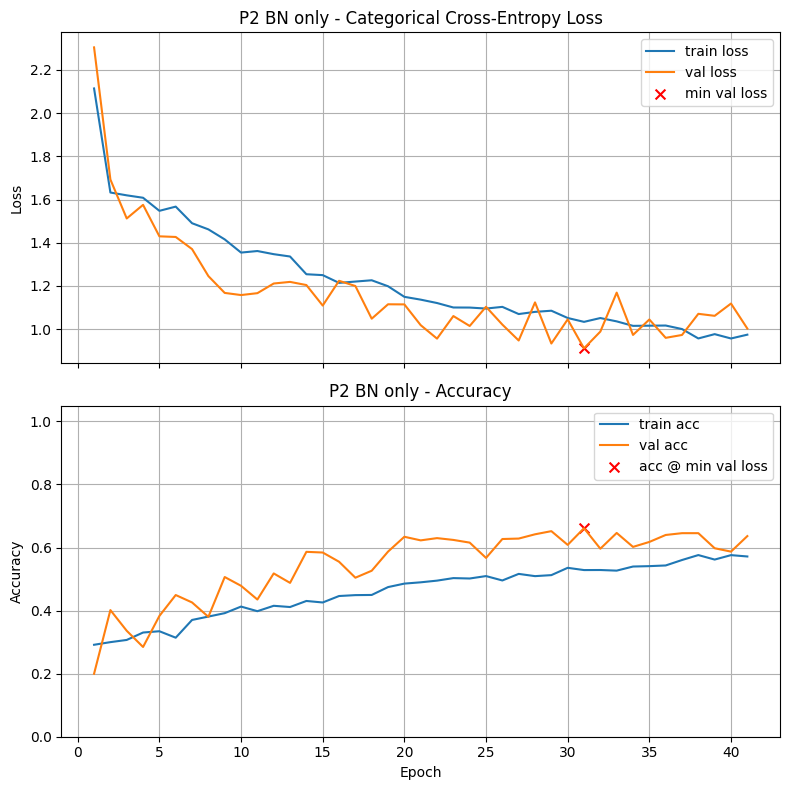

Final Training Loss:            0.9749
Final Training Accuracy:        0.5716
Final Validation Loss:          1.0031
Final Validation Accuracy:      0.6362
Minimum Validation Loss:        0.9115 (Epoch 31)
Validation Accuracy @ Min Loss: 0.6612

Test Loss: 0.9243
Test Accuracy: 0.6602

Validation-Test Gap (accuracy): 0.000985

Execution Time: 00:04:44


0.6611982583999634

In [24]:
title, lr, cfg = P2[0]
run_experiment(title, lr, cfg)


P2 BN + Tweak 1 lr=0.0005



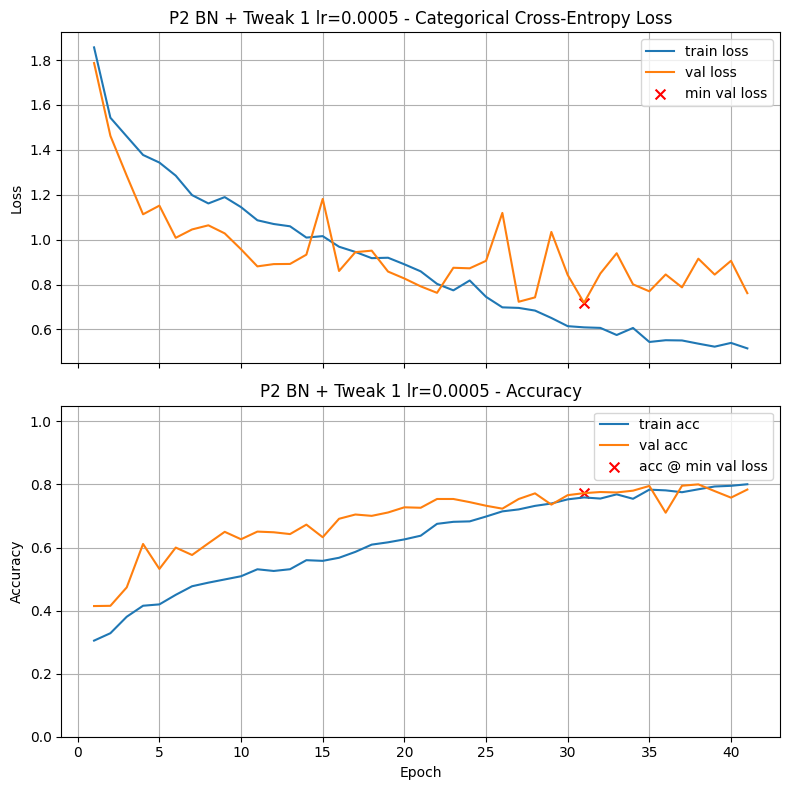

Final Training Loss:            0.5154
Final Training Accuracy:        0.8007
Final Validation Loss:          0.7615
Final Validation Accuracy:      0.7839
Minimum Validation Loss:        0.7183 (Epoch 31)
Validation Accuracy @ Min Loss: 0.7725

Test Loss: 0.7228
Test Accuracy: 0.7824

Validation-Test Gap (accuracy): 0.009909

Execution Time: 00:04:29


0.7724679112434387

In [25]:
title, lr, cfg = P2[1]
run_experiment(title, lr, cfg)


P2 BN + Tweak 6 dropout=0.25



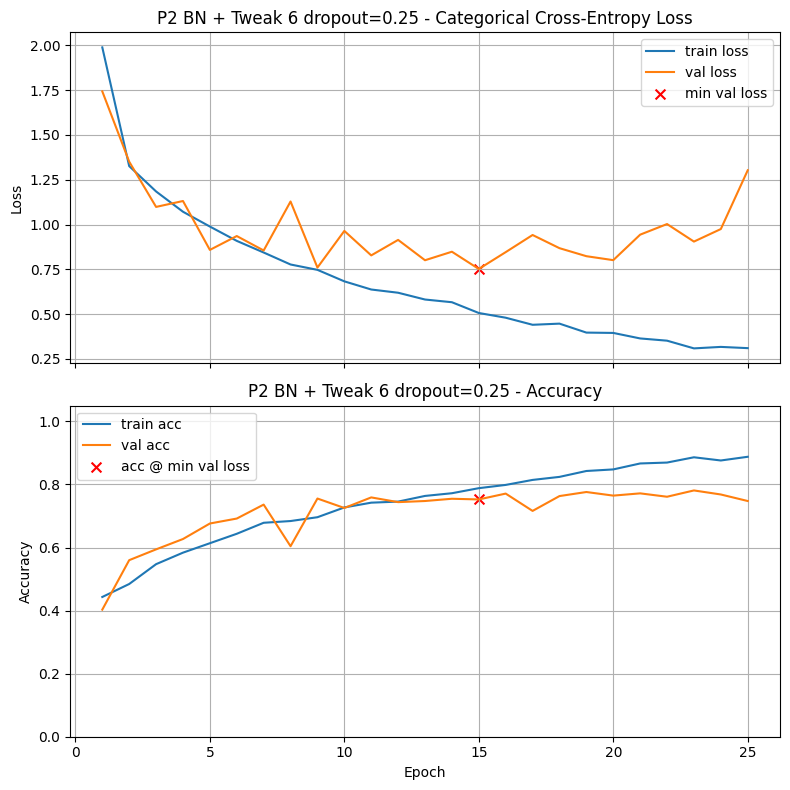

Final Training Loss:            0.3104
Final Training Accuracy:        0.8878
Final Validation Loss:          1.3025
Final Validation Accuracy:      0.7475
Minimum Validation Loss:        0.7520 (Epoch 15)
Validation Accuracy @ Min Loss: 0.7525

Test Loss: 0.7440
Test Accuracy: 0.7670

Validation-Test Gap (accuracy): 0.014526

Execution Time: 00:02:52


0.7524964213371277

In [26]:
title, lr, cfg = P2[6]
run_experiment(title, lr, cfg)

### Graded Questions

In [27]:
# Set a2a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

p2_best = max(P2, key=lambda t: val_acc(P2[t][0]))
a2a = p2_best if p2_best != 0 else -1             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [28]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a}')


a2a = 1


In [29]:
# Set a2b to the validation accuracy found by the choice specified in Question a2a (your best model for this problem)

a2b = val_acc(P2[p2_best][0])             # Replace 0.0 with your answer

In [30]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2b = {a2b:.4f}')

a2b = 0.7725


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video,
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique).

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block.

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design.
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.



In [31]:
# Your code here, add additional cells if you wish

so_far = [("Baseline Model", 1e-3, dict(BASE))] + list(P1.values()) + list(P2.values())
P3_BASE_TITLE, P3_BASE_LR, P3_BASE_CFG = max(so_far, key=lambda c: val_acc(c[0]))
print("Best so far:", P3_BASE_TITLE)

P3_CFG = dict(P3_BASE_CFG, head="gap")
filters = tuple(P3_CFG["conv_filters"])

P3 = {
    0: ("P3 GAP only",                    P3_BASE_LR, dict(P3_CFG)),
    3: ("P3 GAP + Tweak 3 extra conv",    P3_BASE_LR, dict(P3_CFG, conv_filters=filters + (2 * filters[-1],))),
    2: ("P3 GAP + Tweak 2 wider conv",    P3_BASE_LR, dict(P3_CFG, conv_filters=tuple(2 * f for f in filters))),
}
print(P3)

Best so far: P2 BN + Tweak 1 lr=0.0005
{0: ('P3 GAP only', 0.0005, {'conv_filters': (32, 64, 128), 'dense_units': 64, 'dropout': 0.5, 'batch_norm': True, 'head': 'gap'}), 3: ('P3 GAP + Tweak 3 extra conv', 0.0005, {'conv_filters': (32, 64, 128, 256), 'dense_units': 64, 'dropout': 0.5, 'batch_norm': True, 'head': 'gap'}), 2: ('P3 GAP + Tweak 2 wider conv', 0.0005, {'conv_filters': (64, 128, 256), 'dense_units': 64, 'dropout': 0.5, 'batch_norm': True, 'head': 'gap'})}



P3 GAP only



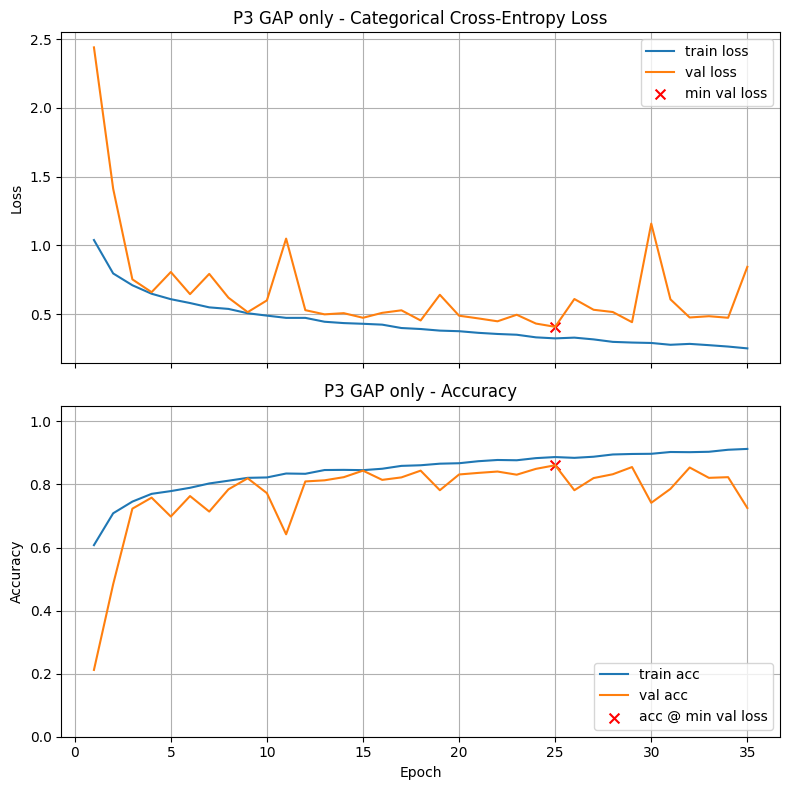

Final Training Loss:            0.2508
Final Training Accuracy:        0.9127
Final Validation Loss:          0.8439
Final Validation Accuracy:      0.7254
Minimum Validation Loss:        0.4077 (Epoch 25)
Validation Accuracy @ Min Loss: 0.8609

Test Loss: 0.4329
Test Accuracy: 0.8431

Validation-Test Gap (accuracy): 0.017789

Execution Time: 00:03:55


0.8609129786491394

In [32]:
title, lr, cfg = P3[0]
run_experiment(title, lr, cfg)


P3 GAP + Tweak 3 extra conv



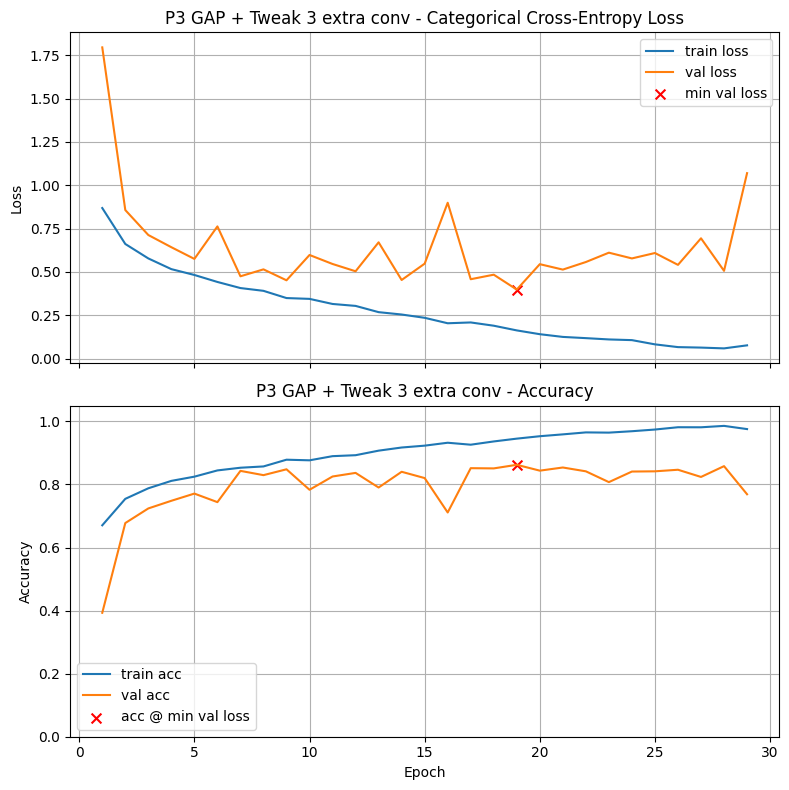

Final Training Loss:            0.0770
Final Training Accuracy:        0.9756
Final Validation Loss:          1.0700
Final Validation Accuracy:      0.7689
Minimum Validation Loss:        0.3986 (Epoch 19)
Validation Accuracy @ Min Loss: 0.8623

Test Loss: 0.3917
Test Accuracy: 0.8712

Validation-Test Gap (accuracy): 0.008822

Execution Time: 00:03:38


0.8623394966125488

In [33]:
title, lr, cfg = P3[3]
run_experiment(title, lr, cfg)


P3 GAP + Tweak 2 wider conv



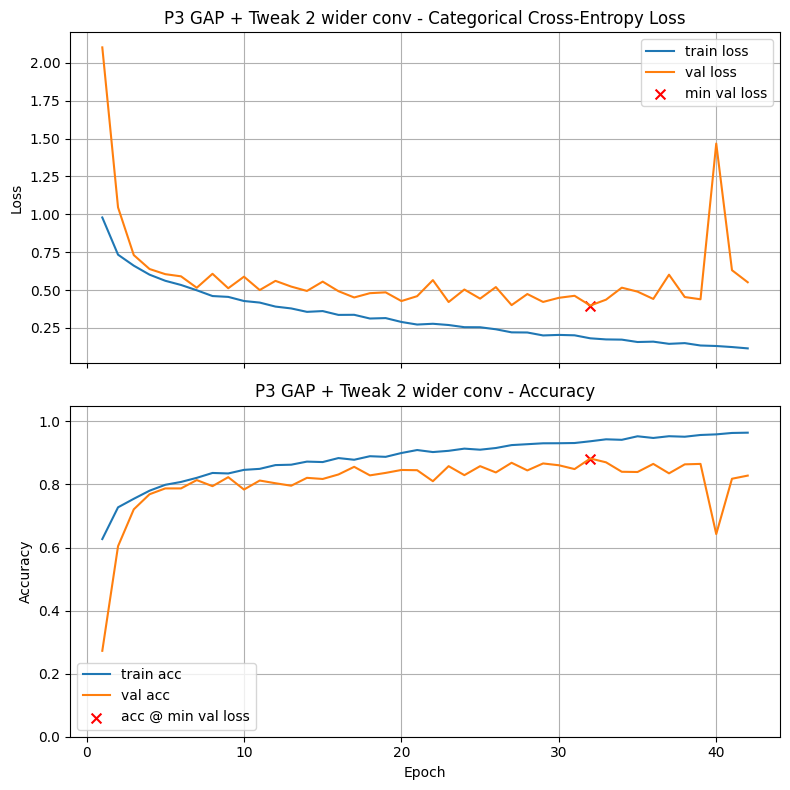

Final Training Loss:            0.1152
Final Training Accuracy:        0.9642
Final Validation Loss:          0.5517
Final Validation Accuracy:      0.8281
Minimum Validation Loss:        0.3981 (Epoch 32)
Validation Accuracy @ Min Loss: 0.8823

Test Loss: 0.4160
Test Accuracy: 0.8605

Validation-Test Gap (accuracy): 0.021830

Execution Time: 00:08:39


0.8823109865188599

In [34]:
title, lr, cfg = P3[2]
run_experiment(title, lr, cfg)

### Graded Questions

In [35]:
# Set a3a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

p3_best = max(P3, key=lambda t: val_acc(P3[t][0]))
a3a = p3_best if p3_best != 0 else -1             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [36]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a}')


a3a = 2


In [37]:
# Set a3b to the validation accuracy found by the choice specified in Question a3a (your best model for this problem)

a3b = val_acc(P3[p3_best][0])             # Replace 0.0 with your answer

In [38]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3b = {a3b:.4f}')

a3b = 0.8823


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!).
* Answer the graded questions.



In [39]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

# Your code here, add more cells as needed

In [40]:
so_far = so_far + list(P3.values())
P4_BASE_TITLE, P4_BASE_LR, P4_BASE_CFG = max(so_far, key=lambda c: val_acc(c[0]))
print("Best so far:", P4_BASE_TITLE)

def make_reduce_lr(factor, patience=3, min_delta=1e-4):
    return ReduceLROnPlateau(monitor="val_loss", factor=factor, patience=patience,
                             min_delta=min_delta, cooldown=1, min_lr=1e-5, verbose=0)

P4 = {f: (f"P4 ReduceLR factor={f}", P4_BASE_LR, dict(P4_BASE_CFG)) for f in [0.5, 0.3, 0.2]}

Best so far: P3 GAP + Tweak 2 wider conv



P4 ReduceLR factor=0.5



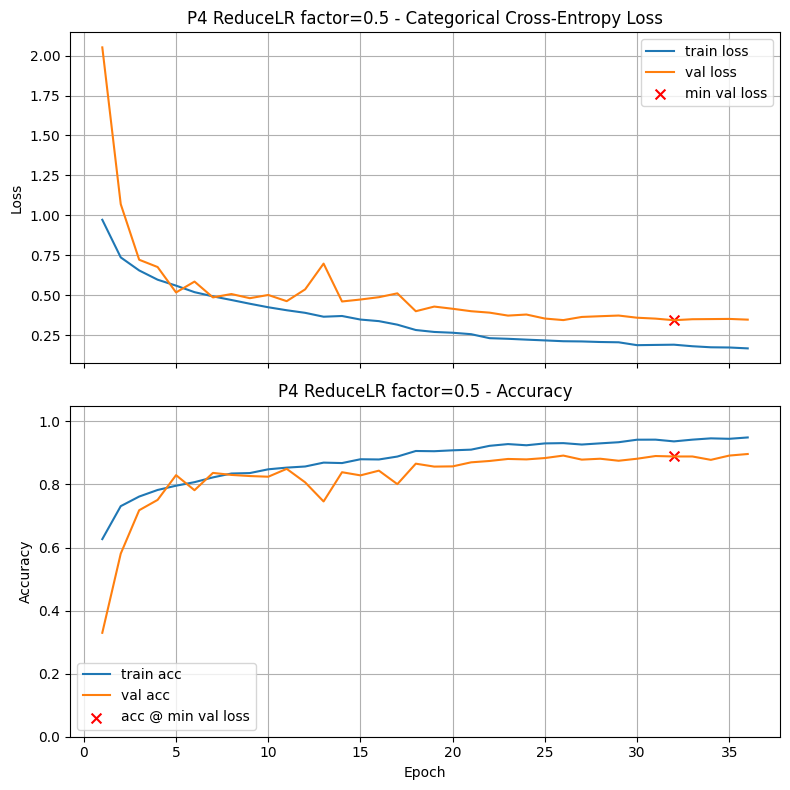

Final Training Loss:            0.1674
Final Training Accuracy:        0.9491
Final Validation Loss:          0.3473
Final Validation Accuracy:      0.8966
Minimum Validation Loss:        0.3437 (Epoch 32)
Validation Accuracy @ Min Loss: 0.8887

Test Loss: 0.3706
Test Accuracy: 0.8832

Validation-Test Gap (accuracy): 0.008406

Execution Time: 00:07:02


0.8887304067611694

In [41]:
title, lr, cfg = P4[0.5]
run_experiment(title, lr, cfg, callbacks=[make_reduce_lr(0.5)])


P4 ReduceLR factor=0.3



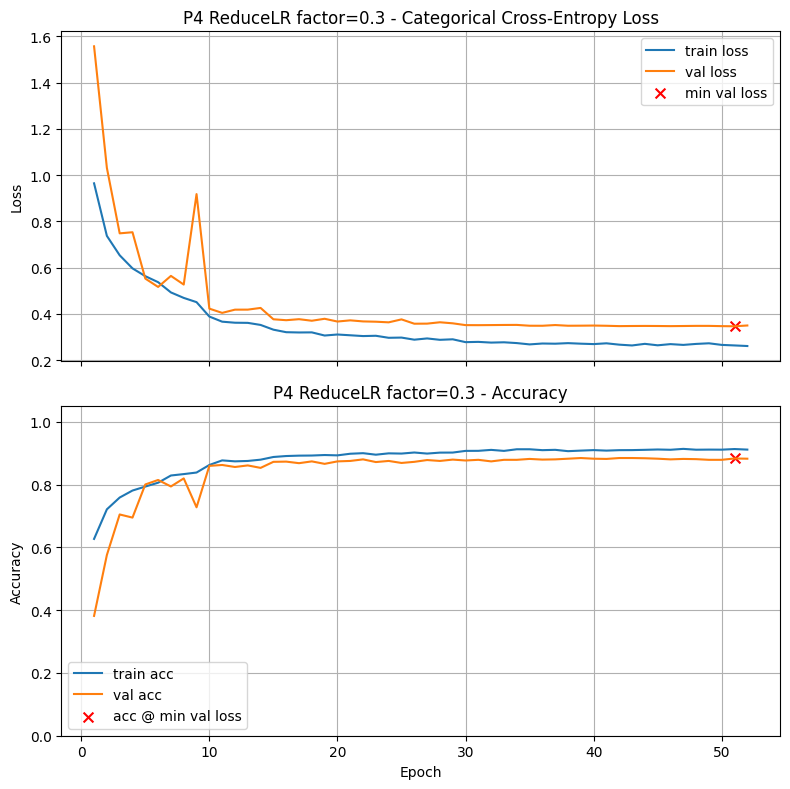

Final Training Loss:            0.2608
Final Training Accuracy:        0.9113
Final Validation Loss:          0.3496
Final Validation Accuracy:      0.8823
Minimum Validation Loss:        0.3462 (Epoch 51)
Validation Accuracy @ Min Loss: 0.8830

Test Loss: 0.3891
Test Accuracy: 0.8752

Validation-Test Gap (accuracy): 0.009284

Execution Time: 00:10:36


0.883024275302887

In [42]:
title, lr, cfg = P4[0.3]
run_experiment(title, lr, cfg, callbacks=[make_reduce_lr(0.3)])


P4 ReduceLR factor=0.2



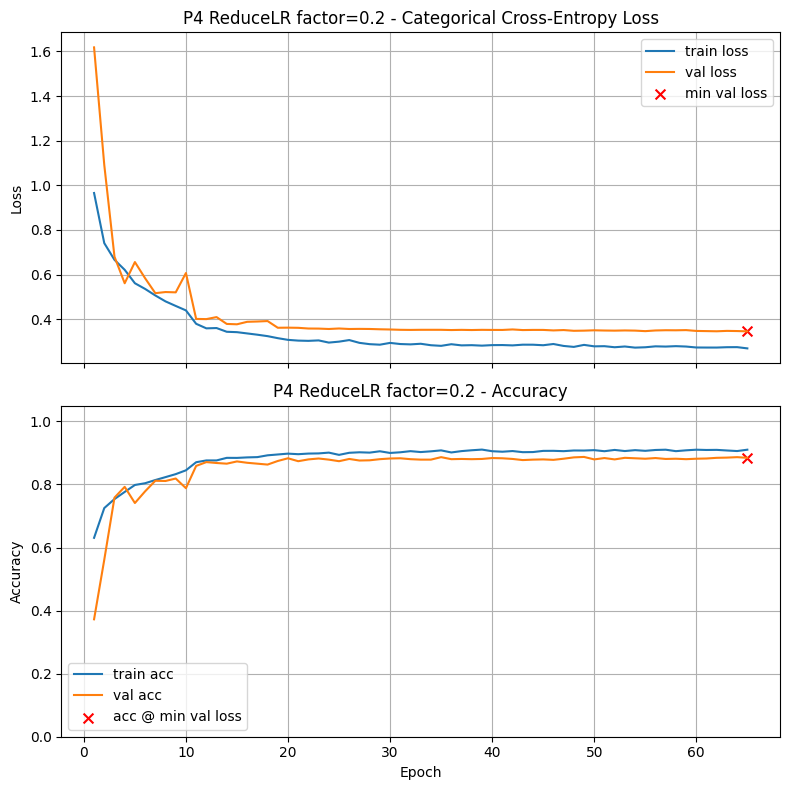

Final Training Loss:            0.2690
Final Training Accuracy:        0.9102
Final Validation Loss:          0.3453
Final Validation Accuracy:      0.8845
Minimum Validation Loss:        0.3453 (Epoch 65)
Validation Accuracy @ Min Loss: 0.8845

Test Loss: 0.3741
Test Accuracy: 0.8698

Validation-Test Gap (accuracy): 0.011771

Execution Time: 00:13:14


0.8844507932662964

In [43]:
title, lr, cfg = P4[0.2]
run_experiment(title, lr, cfg, callbacks=[make_reduce_lr(0.2)])

### Graded Questions

In [44]:
# Set a4a to the factor parameter which gave the best validation accuracy at the point of minimum validation loss

p4_best = max(P4, key=lambda f: val_acc(P4[f][0]))
a4a = p4_best if val_acc(P4[p4_best][0]) > val_acc(P4_BASE_TITLE) else -1             # Replace with your best factor value, or set to -1 if reduce on plateau did not help at all

In [45]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4a = {a4a:.2f}')

a4a = 0.50


In [46]:
# Set a4b to the validation accuracy found by the choice specified in Question a4a (your best model for this problem)

a4b = val_acc(P4[p4_best][0])             # Replace 0.0 with your answer

In [47]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4b = {a4b:.4f}')

a4b = 0.8887


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

![Screenshot 2025-09-19 at 6.50.24 AM.png](attachment:62fa0824-bb06-4663-a6a5-da8cca8f4ab3.png)


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss**
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect.



In [48]:
def build_vgg16():
    he = initializers.HeNormal()
    l2reg = regularizers.l2(1e-4)
    return models.Sequential([
        layers.Input(shape=(150, 150, 3)),

        layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.MaxPooling2D(),

        layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu', kernel_initializer=he, kernel_regularizer=l2reg),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])


P5 = {}


def run_vgg(lr):
    title = f"P5 VGG-16 lr={lr:g}"
    train_and_test(build_vgg16(), lr_schedule=lr, title=title)
    P5[lr] = title

In [49]:
run_vgg(1e-3)


P5 VGG-16 lr=0.001



KeyboardInterrupt: 

In [ ]:
run_vgg(3e-4)

In [ ]:
run_vgg(1e-4)

### Graded Questions

In [ ]:
# Set a5a to the learning rate which gave the best validation accuracy at the point of minimum validation loss

a5a = max(P5, key=lambda lr: val_acc(P5[lr]))            # Replace with your best learning rate

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5a = {a5a:.8f}')

In [ ]:
# Set a5b to the validation accuracy found by the choice specified in Question a5a (your best model for this problem)

a5b = val_acc(P5[a5a])              # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5b = {a5b:.4f}')

## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [ ]:
print_results()